<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Deep Learning, Demo Notebook

Loads the two best models from the assignment (regression and classification) plus the held-out test set from a GitHub Release, then runs inference and reports metrics. No training code, only evaluation.

## 1. Setup

In [1]:
import urllib.request
import zipfile
import tempfile
import shutil
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA A100-SXM4-40GB


## 2. Download assets from GitHub Release

Three assets, the regression model, the classification model, and the test data zip. Cached in a temp directory so re-running the notebook does not re-download.

In [3]:
URLS = {
    "regression":     "https://github.com/iav2002/AppliedDeepLearning/releases/download/demo/regression_k5_relu.pt",
    "classification": "https://github.com/iav2002/AppliedDeepLearning/releases/download/demo/resnet50_best.pt",
    "testdata":       "https://github.com/iav2002/AppliedDeepLearning/releases/download/demo/test_data.zip",
}

CACHE = Path(tempfile.gettempdir()) / "facedemo"
CACHE.mkdir(exist_ok=True)

paths = {}
for name, url in URLS.items():
    suffix = url.split(".")[-1]
    out = CACHE / f"{name}.{suffix}"
    if not out.exists():
        print(f"downloading {name}")
        urllib.request.urlretrieve(url, out)
    else:
        print(f"{name} cached")
    paths[name] = out

print("\nall files ready")
for k, v in paths.items():
    print(f"  {k:14s}  {v}")

downloading regression
downloading classification
downloading testdata

all files ready
  regression      /tmp/facedemo/regression.pt
  classification  /tmp/facedemo/classification.pt
  testdata        /tmp/facedemo/testdata.zip


## 3. Unzip test data

The zip contains the test images and test.csv. Extract into a clean directory, point everything else at that.

In [4]:
TEST_ROOT = CACHE / "test_data"
if not TEST_ROOT.exists():
    with zipfile.ZipFile(paths["testdata"]) as z:
        z.extractall(TEST_ROOT)
    print("extracted")
else:
    print("already extracted")

# locate test.csv inside the extracted structure
test_csv = next(TEST_ROOT.rglob("test.csv"))
print(f"test.csv at {test_csv}")

test_df = pd.read_csv(test_csv)
print(f"test set size {len(test_df)}")
print(test_df.head())

extracted
test.csv at /tmp/facedemo/test_data/test.csv
test set size 976
                    path  age     fname age_category
0  face_age/001/8971.png    1  8971.png       infant
1  face_age/052/6023.png   52  6023.png       mature
2  face_age/060/5138.png   60  5138.png       mature
3  face_age/054/6379.png   54  6379.png       mature
4  face_age/016/7514.png   16  7514.png         teen


## 4. Dataset class

Same FaceAgeDataset as used in training. Reads paths relative to the test data root.

In [5]:
CATEGORIES = ["infant", "child", "teen", "youth", "mid", "mature", "senior"]
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}


class FaceAgeDataset(Dataset):
    def __init__(self, csv_path, root, task, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root = Path(root)
        self.task = task
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        if self.task == "reg":
            lbl = torch.tensor(row["age"], dtype=torch.float32)
        else:
            lbl = torch.tensor(CAT_TO_IDX[row["age_category"]], dtype=torch.long)
        return img, lbl


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# test data root is where test.csv lives, image paths are relative to it
test_root = test_csv.parent

## 5. Regression model

VariantCNN from notebook 4, kernel size 5, ReLU activation, one output for age. Input 200x200 with ImageNet normalisation.

In [6]:
class VariantCNN(nn.Module):
    def __init__(self, num_outputs, kernel_size=3, activation=nn.ReLU):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(3, 32, kernel_size, padding=pad)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size, padding=pad)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size, padding=pad)
        self.pool3 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 25 * 25, 128)
        self.fc2 = nn.Linear(128, num_outputs)
        self.act = activation()

    def forward(self, x):
        x = self.pool1(self.act(self.conv1(x)))
        x = self.pool2(self.act(self.conv2(x)))
        x = self.pool3(self.act(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x


tf_reg = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

ckpt_reg = torch.load(paths["regression"], map_location=device, weights_only=False)
print(f"regression checkpoint, val MAE at save {ckpt_reg['val_mae']:.4f}")

reg_model = VariantCNN(num_outputs=1, kernel_size=5, activation=nn.ReLU).to(device)
reg_model.load_state_dict(ckpt_reg["state_dict"])
reg_model.eval()
print("regression model loaded")

regression checkpoint, val MAE at save 6.3242
regression model loaded


## 6. Regression inference on test set

In [7]:
test_ds_reg = FaceAgeDataset(test_csv, test_root, task="reg", transform=tf_reg)
test_loader_reg = DataLoader(test_ds_reg, batch_size=64, shuffle=False, num_workers=2)

abs_err = 0
n = 0
with torch.no_grad():
    for imgs, lbls in test_loader_reg:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = reg_model(imgs).squeeze()
        abs_err += (preds - lbls).abs().sum().item()
        n += imgs.size(0)

test_mae = abs_err / n
print(f"regression test MAE  {test_mae:.4f}")
print(f"reference val MAE    {ckpt_reg['val_mae']:.4f}")

regression test MAE  6.6014
reference val MAE    6.3242


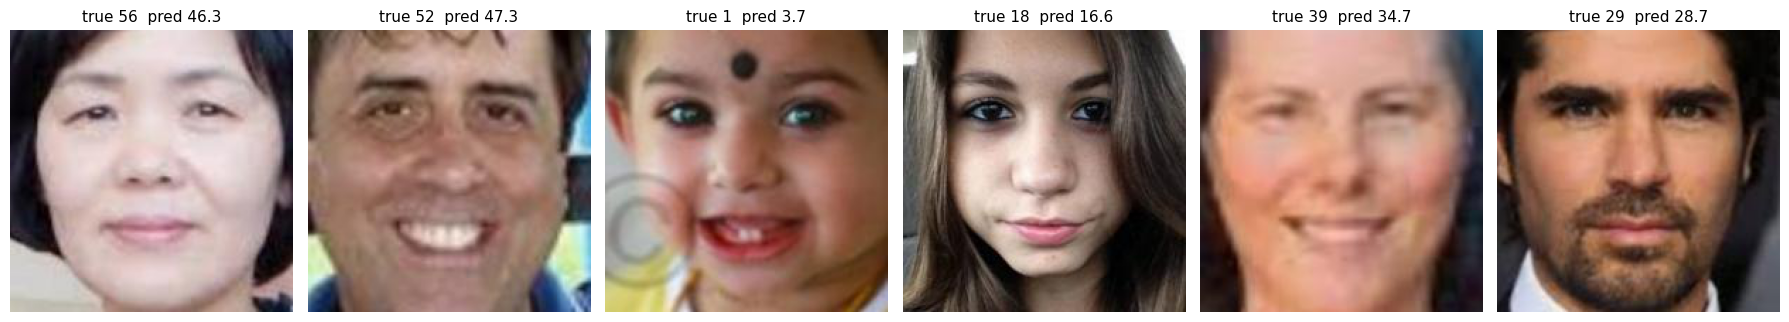

In [8]:
import random

# pick a few test rows at random for display
random.seed(42)
sample_idx = random.sample(range(len(test_df)), 6)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
with torch.no_grad():
    for ax, idx in zip(axes, sample_idx):
        row = test_df.iloc[idx]
        img = Image.open(test_root / row["path"]).convert("RGB")
        x = tf_reg(img).unsqueeze(0).to(device)
        pred = reg_model(x).item()
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"true {row['age']}  pred {pred:.1f}", fontsize=11)

plt.tight_layout()
plt.show()

## 7. Classification model


In [9]:
def build_resnet50(n_classes=7):
    m = models.resnet50(weights=None)  # weights loaded from checkpoint below
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m


tf_cls = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

ckpt_cls = torch.load(paths["classification"], map_location=device, weights_only=False)
print(f"classification checkpoint, val accuracy at save {ckpt_cls['val_acc']:.4f}")

cls_model = build_resnet50(n_classes=7).to(device)
cls_model.load_state_dict(ckpt_cls["state_dict"])
cls_model.eval()
print("classification model loaded")

classification checkpoint, val accuracy at save 0.7031
classification model loaded


## 8. Classification inference on test set



In [10]:
test_ds_cls = FaceAgeDataset(test_csv, test_root, task="cls", transform=tf_cls)
test_loader_cls = DataLoader(test_ds_cls, batch_size=64, shuffle=False, num_workers=2)

correct = 0
n = 0
per_class_correct = [0] * 7
per_class_total = [0] * 7

with torch.no_grad():
    for imgs, lbls in test_loader_cls:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = cls_model(imgs).argmax(1)
        correct += (preds == lbls).sum().item()
        n += imgs.size(0)
        for c in range(7):
            mask = lbls == c
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += ((preds == lbls) & mask).sum().item()

test_acc = correct / n
print(f"classification test accuracy  {test_acc:.4f}")
print(f"reference val accuracy        {ckpt_cls['val_acc']:.4f}")
print()
print("per class accuracy")
for c in range(7):
    acc = per_class_correct[c] / per_class_total[c] if per_class_total[c] > 0 else 0
    print(f"  {CATEGORIES[c]:8s}  {per_class_correct[c]:4d} / {per_class_total[c]:4d}  ({acc:.4f})")

classification test accuracy  0.6926
reference val accuracy        0.7031

per class accuracy
  infant     200 /  213  (0.9390)
  child       70 /  112  (0.6250)
  teen        53 /   91  (0.5824)
  youth      100 /  163  (0.6135)
  mid         73 /  131  (0.5573)
  mature      91 /  137  (0.6642)
  senior      89 /  129  (0.6899)


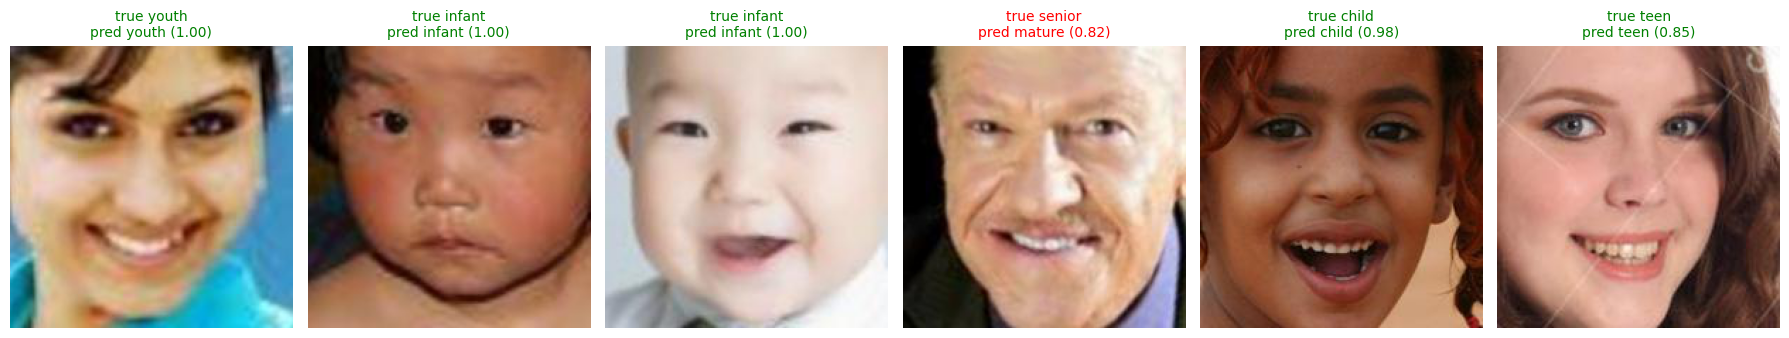

In [11]:
random.seed(50)
sample_idx = random.sample(range(len(test_df)), 6)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
with torch.no_grad():
    for ax, idx in zip(axes, sample_idx):
        row = test_df.iloc[idx]
        img = Image.open(test_root / row["path"]).convert("RGB")
        x = tf_cls(img).unsqueeze(0).to(device)
        logits = cls_model(x)
        probs = F.softmax(logits, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_cat = CATEGORIES[pred_idx]
        pred_conf = probs[pred_idx].item()
        true_cat = row["age_category"]
        colour = "green" if pred_cat == true_cat else "red"
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"true {true_cat}\npred {pred_cat} ({pred_conf:.2f})",
                     fontsize=10, color=colour)

plt.tight_layout()
plt.show()